In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np


path = '/content/drive/MyDrive/Статьи по комплексам/ADMET/Datasets'


In [ ]:
# 1. ЗАГРУЗКА И ПРЕДОБРАБОТКА
# Предположим, файл называется 'peptides.csv'
# Если данные из буфера обмена, можно использовать pd.read_clipboard()
df = pd.read_excel(f'{path}/Approved_data.xlsx') # Замените на путь к вашему файлу
df

,Group,sources,Name,Canonical_smiles,Caco-2_prm,PAMPA,"Vd, L/kg","Half-life, h","Clearance, L/h/kg","Stability, intestinal",Cyclic/Linear (auto),Cyclic/Linear (checked),Functional_activity,PK_groups,Canonical/Non-canonical,Sequence
0,1,drugbank,Dalbavancin,CN[C@H]1C(=O)N[C@@H]2Cc3ccc(cc3)Oc3cc4cc(c3O[C...,NaN,NaN,NaN,346.00,0.0732,NaN,Cyclic,Cyclic,Антибиотик,Группа 5: Барьерные и локально-ориентированные...,"Non-canonical (неканонические ак, липогликопеп...",NaN
1,1,drugbank,Oritavancin,CN[C@H](CC(C)C)C(=O)N[C@H]1C(=O)N[C@@H](CC(N)=...,NaN,NaN,1.251,245.00,0.0063,NaN,Cyclic,Cyclic,Антибиотик,Группа 5: Барьерные и локально-ориентированные...,"Non-canonical (неканонические ак, липогликопеп...",NaN
2,1,drugbank,Caspofungin,CC[C@H](C)C[C@H](C)CCCCCCCCC(=O)N[C@H]1C[C@@H]...,NaN,NaN,NaN,10.00,0.0102,NaN,Cyclic,Cyclic,Антибиотик,Группа 5: Барьерные и локально-ориентированные...,Non-canonical (неканонические ак),NaN
3,1,"drugbank, chembl",Polymyxin B,CCC(C)CCCCC(=O)N[C@@H](CCN)C(=O)N[C@H](C(=O)N[...,NaN,NaN,0.582,10.25,0.0347,NaN,Cyclic,Cyclic,Антибиотик,Группа 5: Барьерные и локально-ориентированные...,"Non-canonical (неканонические ак, липопептид)",NaN
4,1,"tdc, drugbank",Telavancin,CCCCCCCCCCNCCN[C@@]1(C)C[C@H](O[C@H]2[C@H](Oc3...,NaN,NaN,0.140,8.00,0.0140,NaN,Cyclic,Cyclic,Антибиотик,Группа 5: Барьерные и локально-ориентированные...,Non-canonical (липогликопептид),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,4,"drugbank, stability",Atazanavir,COC(=O)N[C@H](C(=O)N[C@@H](Cc1ccccc1)[C@@H](O)...,NaN,NaN,1.261,7.00,0.1842,0.0,Linear,Linear,Противовирусное,Группа 5: Барьерные и локально-ориентированные...,NaN,НЕ ПЕПТИД
120,4,chembl,CHEMBL114 (Saquinavir),CC(C)(C)NC(=O)[C@@H]1C[C@@H]2CCCC[C@@H]2CN1C[C...,NaN,NaN,3.600,NaN,NaN,NaN,NaN,Linear,Противовирусное,Группа 5: Барьерные и локально-ориентированные...,NaN,NaN
121,4,"drugbank, chembl",Carfilzomib,CC(C)C[C@H](NC(=O)[C@H](CCc1ccccc1)NC(=O)CN1CC...,NaN,NaN,0.400,NaN,2.9570,NaN,Linear,Linear,Противоопухолевое,Группа 4: Рецепторно-сигнальные и таргетные мо...,Non-canonical (неканонические ак),NaN
122,4,"drugbank, chembl",Romidepsin,C/C=C1\NC(=O)[C@H]2CSSCC/C=C/[C@H](CC(=O)N[C@H...,NaN,NaN,0.635,3.00,0.1200,NaN,Cyclic,Cyclic,Противоопухолевое,Группа 4: Рецепторно-сигнальные и таргетные мо...,Non-canonical (неканонические ак),NaN


In [ ]:
df_clean = df

In [ ]:
# 2. СТАТИСТИЧЕСКИЙ АНАЛИЗ ПО ГРУППАМ

print("--- ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ ---")

numeric_cols = ['Vd, L/kg', 'Half-life, h', 'Clearance, L/h/kg']
stats_summary = df_clean.groupby('Group')[numeric_cols].describe().T
print(stats_summary)

# Тест Краскела-Уоллиса (непараметрический аналог ANOVA), чтобы проверить,
# есть ли статистически значимая разница между группами
print("\n--- ТЕСТ НА РАЗЛИЧИЯ МЕЖДУ ГРУППАМИ (p-value < 0.05 = значимо) ---")
for col in numeric_cols:
    groups_data = [group[col].values for name, group in df_clean.groupby('Group')]
    stat, p = stats.kruskal(*groups_data)
    print(f"{col}: p-value = {p:.4e}")

--- ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ ---
Group                             1            2          3          4
Vd, L/kg          count    9.000000    54.000000  11.000000   5.000000
                  mean     0.765556     1.017754   0.328364   1.226800
                  std      0.650144     2.273425   0.189320   1.382461
                  min      0.100000     0.030000   0.170000   0.238000
                  25%      0.390000     0.122500   0.195000   0.400000
                  50%      0.582000     0.258500   0.250000   0.635000
                  75%      0.957000     0.607500   0.399500   1.261000
                  max      2.200000    11.370000   0.742000   3.600000
Half-life, h      count   17.000000    74.000000  19.000000   4.000000
                  mean    57.650941    58.195244   1.256037   9.575000
                  std     99.229915   174.595591   1.192952  11.859841
                  min      0.700000     0.033330   0.016000   1.300000
                  25%      5.00000

In [ ]:
log_cols = []
for col in numeric_cols:
    log_name = f'log10({col})'
    df_clean[log_name] = np.log10(df_clean[col])
    log_cols.append(log_name)

# 2. НАСТРОЙКА ПАР ДЛЯ СРАВНЕНИЯ
# Выберем группы, которые мы хотим сравнить (например, все против всех или конкретные пары)
groups = sorted(df_clean['Group'].unique())
pairs = [(groups[i], groups[j]) for i in range(len(groups)) for j in range(i+1, len(groups))]

In [ ]:
! pip install statannotations

/tmp/ipython-input-2341396794.py:50: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

2 vs. 3: Custom statistical test, P_val:8.800e-05
3 vs. 4: Custom statistical test, P_val:2.841e-02
1 vs. 3: Custom statistical test, P_val:7.303e-06


/tmp/ipython-input-2341396794.py:50: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:9.131e-03
1 vs. 3: Custom statistical test, P_val:4.258e-02
1 vs. 4: Custom statistical test, P_val:1.026e-02


/tmp/ipython-input-2341396794.py:50: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(


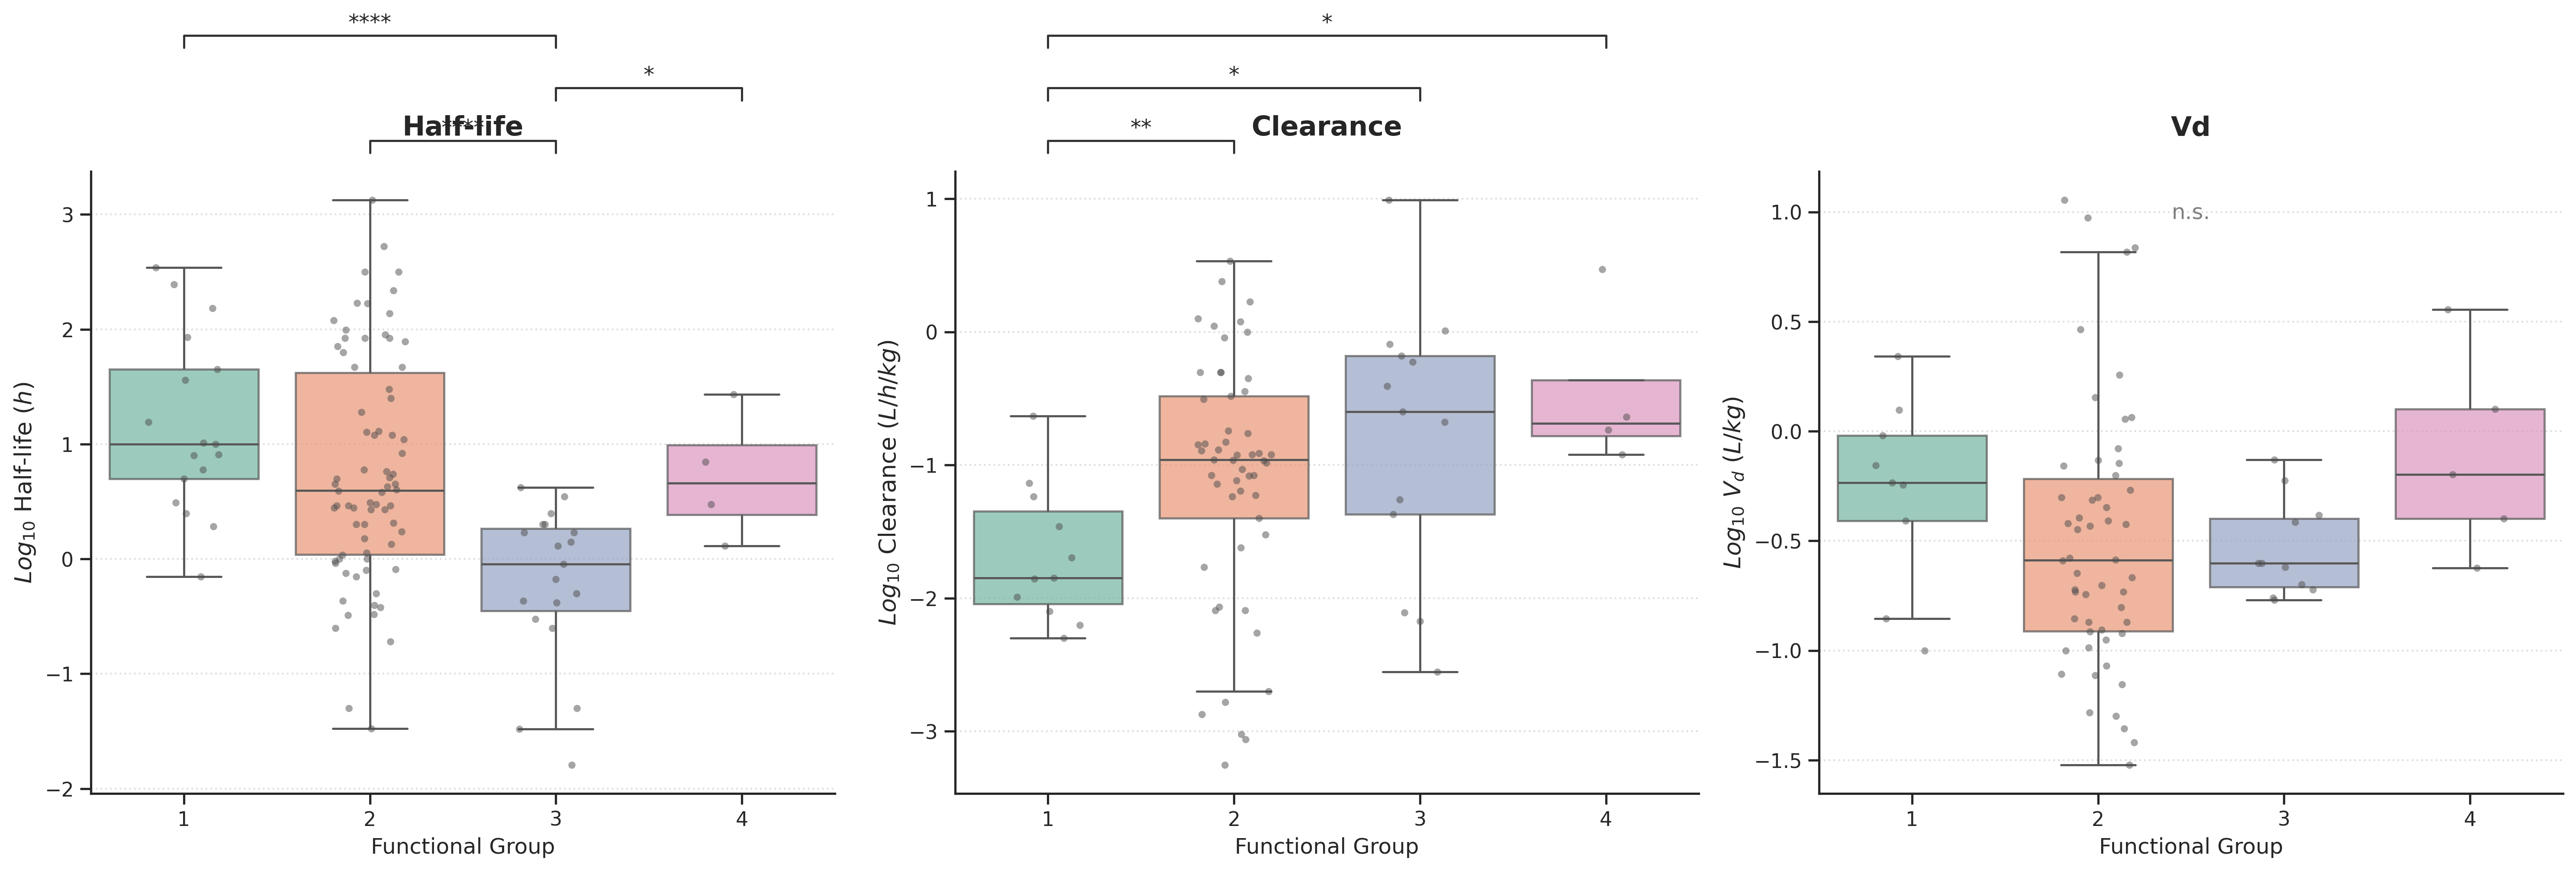

In [ ]:
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu

# --- 1. ФУНКЦИЯ ПОИСКА ЗНАЧИМЫХ ПАР ---
def get_only_sig_pairs(df, col, groups):
    sig_pairs = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            g1, g2 = groups[i], groups[j]
            d1 = df[df['Group'] == g1][col].dropna()
            d2 = df[df['Group'] == g2][col].dropna()

            if len(d1) > 1 and len(d2) > 1:
                _, p = mannwhitneyu(d1, d2)
                if p <= 0.05: # Оставляем только те, где p <= 0.05
                    sig_pairs.append((g1, g2))
    return sig_pairs

# --- 2. ОТРИСОВКА ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

log_cols = ['log10(Vd, L/kg)', 'log10(Half-life, h)', 'log10(Clearance, L/h/kg)']
groups = sorted(df_clean['Group'].unique())

for i, col in enumerate(log_cols):
    ax = axes[i]
    # Боксплот
    sns.boxplot(x='Group', y=col, data=df_clean, ax=ax, palette="Set2", hue='Group', legend=False)

    # Ищем пары со значимостью
    pairs = get_only_sig_pairs(df_clean, col, groups)

    if pairs:
        annotator = Annotator(ax, pairs, data=df_clean, x='Group', y=col)
        # text_format='star' вернёт именно звёздочки (*, **, ***)
        annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
        annotator.apply_and_annotate()

    ax.set_title(f'Significant Differences: {col}')

plt.tight_layout()
plt.show()

In [ ]:


def get_detailed_stats(df, columns, groups):
    detailed_data = []

    for col in columns:
        for i in range(len(groups)):
            for j in range(i+1, len(groups)):
                g1, g2 = groups[i], groups[j]
                data1 = df[df['Group'] == g1][col]
                data2 = df[df['Group'] == g2][col]

                # Тест Манна-Уитни
                stat, p = mannwhitneyu(data1, data2)

                # Интерпретация
                significance = "ns"
                if p <= 0.001: significance = "***"
                elif p <= 0.01: significance = "**"
                elif p <= 0.05: significance = "*"

                detailed_data.append({
                    'Parameter': col,
                    'Comparison': f'G{g1} vs G{g2}',
                    'p-value': f"{p:.4e}",
                    'Significance': significance,
                    'Median Diff': round(data1.median() - data2.median(), 3)
                })

    return pd.DataFrame(detailed_data)

# Вывод таблицы
stats_table = get_detailed_stats(df_clean, log_cols, groups)
print("\nПОДРОБНЫЙ ОТЧЕТ О СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ:")
print(stats_table.to_string(index=False))


ПОДРОБНЫЙ ОТЧЕТ О СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ:
               Parameter Comparison p-value Significance  Median Diff
         log10(Vd, L/kg)   G1 vs G2     nan           ns        0.352
         log10(Vd, L/kg)   G1 vs G3     nan           ns        0.367
         log10(Vd, L/kg)   G1 vs G4     nan           ns       -0.038
         log10(Vd, L/kg)   G2 vs G3     nan           ns        0.015
         log10(Vd, L/kg)   G2 vs G4     nan           ns       -0.390
         log10(Vd, L/kg)   G3 vs G4     nan           ns       -0.405
     log10(Half-life, h)   G1 vs G2     nan           ns        0.402
     log10(Half-life, h)   G1 vs G3     nan           ns        1.046
     log10(Half-life, h)   G1 vs G4     nan           ns        0.339
     log10(Half-life, h)   G2 vs G3     nan           ns        0.643
     log10(Half-life, h)   G2 vs G4     nan           ns       -0.063
     log10(Half-life, h)   G3 vs G4     nan           ns       -0.707
log10(Clearance, L/h/kg)   G1 vs G2     nan 

/tmp/ipython-input-774168321.py:45: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

2 vs. 3: Custom statistical test, P_val:8.800e-05
3 vs. 4: Custom statistical test, P_val:2.841e-02
1 vs. 3: Custom statistical test, P_val:7.303e-06


/tmp/ipython-input-774168321.py:45: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:9.131e-03
1 vs. 3: Custom statistical test, P_val:4.258e-02
1 vs. 4: Custom statistical test, P_val:1.026e-02


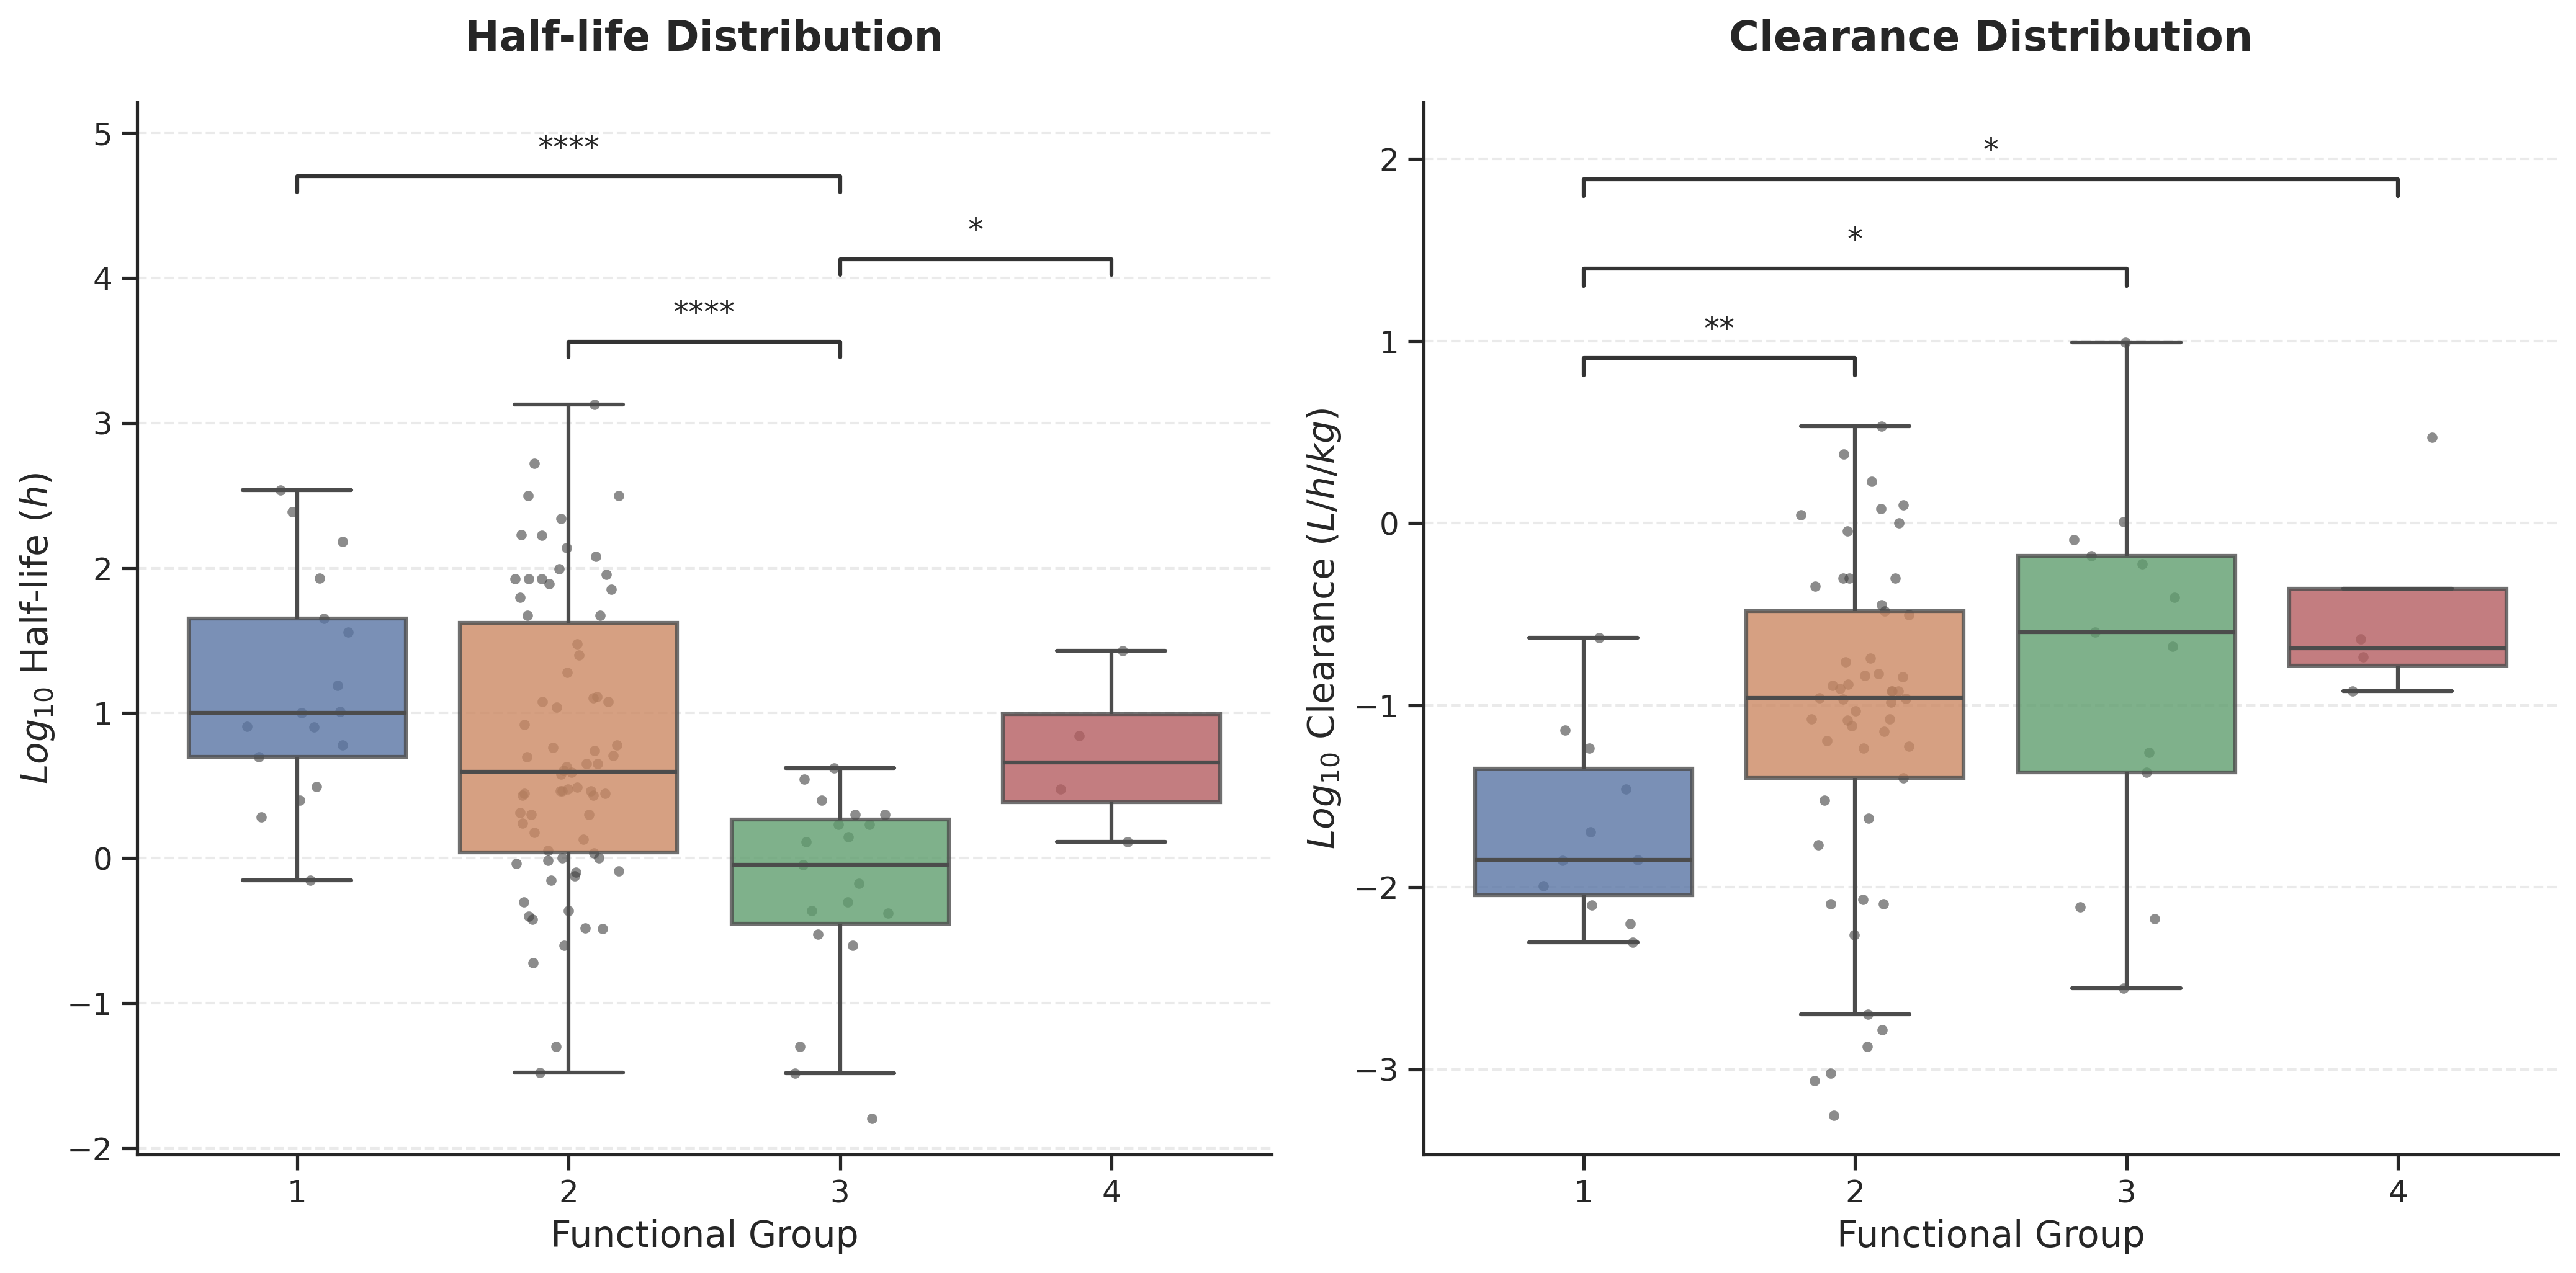

In [ ]:

import seaborn as sns




# --- 1. НАСТРОЙКИ СТИЛЯ (Global Style) ---
# Используем стиль, близкий к стандартам Nature/Science
sns.set_theme(style="ticks", rc={
    "axes.spines.right": False,
    "axes.spines.top": False,
    "font.family": "sans-serif", # Arial/Helvetica лучше для статей
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "pdf.fonttype": 42 # Чтобы текст в PDF сохранялся как текст, а не кривые
})


# --- 3. НАСТРОЙКИ СТАТИСТИКИ (РУЧНОЙ ВВОД ВАШИХ ДАННЫХ) ---
# Здесь мы жестко задаем пары и p-values, которые вы прислали
# Это гарантирует, что на графике будет именно ваш результат анализа

stats_config = {
    'log10(Half-life, h)': {
        'pairs': [(2, 3), (3, 4), (1, 3)],
        'pvalues': [8.800e-05, 2.841e-02, 7.303e-06]
    },
    'log10(Clearance, L/h/kg)': {
        'pairs': [(1, 2), (1, 3), (1, 4)],
        'pvalues': [9.131e-03, 4.258e-02, 1.026e-02]
    }
}

cols_to_plot = ['log10(Half-life, h)', 'log10(Clearance, L/h/kg)']
y_labels = [r'$Log_{10}$ Half-life $(h)$', r'$Log_{10}$ Clearance $(L/h/kg)$']
titles = ['Half-life Distribution', 'Clearance Distribution']

# --- 4. ОТРИСОВКА ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=300) # Высокое разрешение
palette = sns.color_palette("deep") # Профессиональная палитра

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # А. Боксплот (основа)
    # fliersize=0 отключает стандартные выбросы (ромбики), так как мы нарисуем их стрипплотом
    sns.boxplot(
        x='Group', y=col, data=df_clean,
        ax=ax, palette=palette,
        hue='Group', legend=False,
        linewidth=1.5, fliersize=0,
        boxprops=dict(alpha=0.8) # Прозрачность ящиков
    )

    # Б. Стрипплот (точки поверх)
    # Это показывает реальное распределение данных ("Raw data points")
    sns.stripplot(
        x='Group', y=col, data=df_clean,
        ax=ax, color=".25", size=4, alpha=0.6, jitter=0.2, zorder=1
    )

    # В. Аннотации статистики
    config = stats_config.get(col)
    if config:
        annotator = Annotator(ax, config['pairs'], data=df_clean, x='Group', y=col)
        annotator.set_pvalues(config['pvalues'])
        annotator.configure(
            test=None, # Тест не нужен, мы дали p-values
            text_format='star', # Только звездочки
            loc='inside',       # Внутри или outside
            line_height=0.02,
            text_offset=5,
            line_width=1.5
        )
        annotator.annotate()

    # Г. Косметика осей
    ax.set_title(titles[i], fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel(y_labels[i], fontsize=14)
    ax.set_xlabel("Functional Group", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4) # Легкая сетка только по Y

# Финальная компоновка
plt.tight_layout()

# Сохранение в высоком качестве
plt.savefig("publication_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("publication_plot.pdf", format='pdf', bbox_inches='tight') # Вектор для редакции

plt.show()

/tmp/ipython-input-1013643543.py:47: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

2 vs. 3: Custom statistical test, P_val:8.800e-05
3 vs. 4: Custom statistical test, P_val:2.841e-02
1 vs. 3: Custom statistical test, P_val:7.303e-06


/tmp/ipython-input-1013643543.py:47: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(
/usr/local/lib/python3.12/dist-packages/statannotations/Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:9.131e-03
1 vs. 3: Custom statistical test, P_val:4.258e-02
1 vs. 4: Custom statistical test, P_val:1.026e-02


/tmp/ipython-input-1013643543.py:47: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.boxplot(


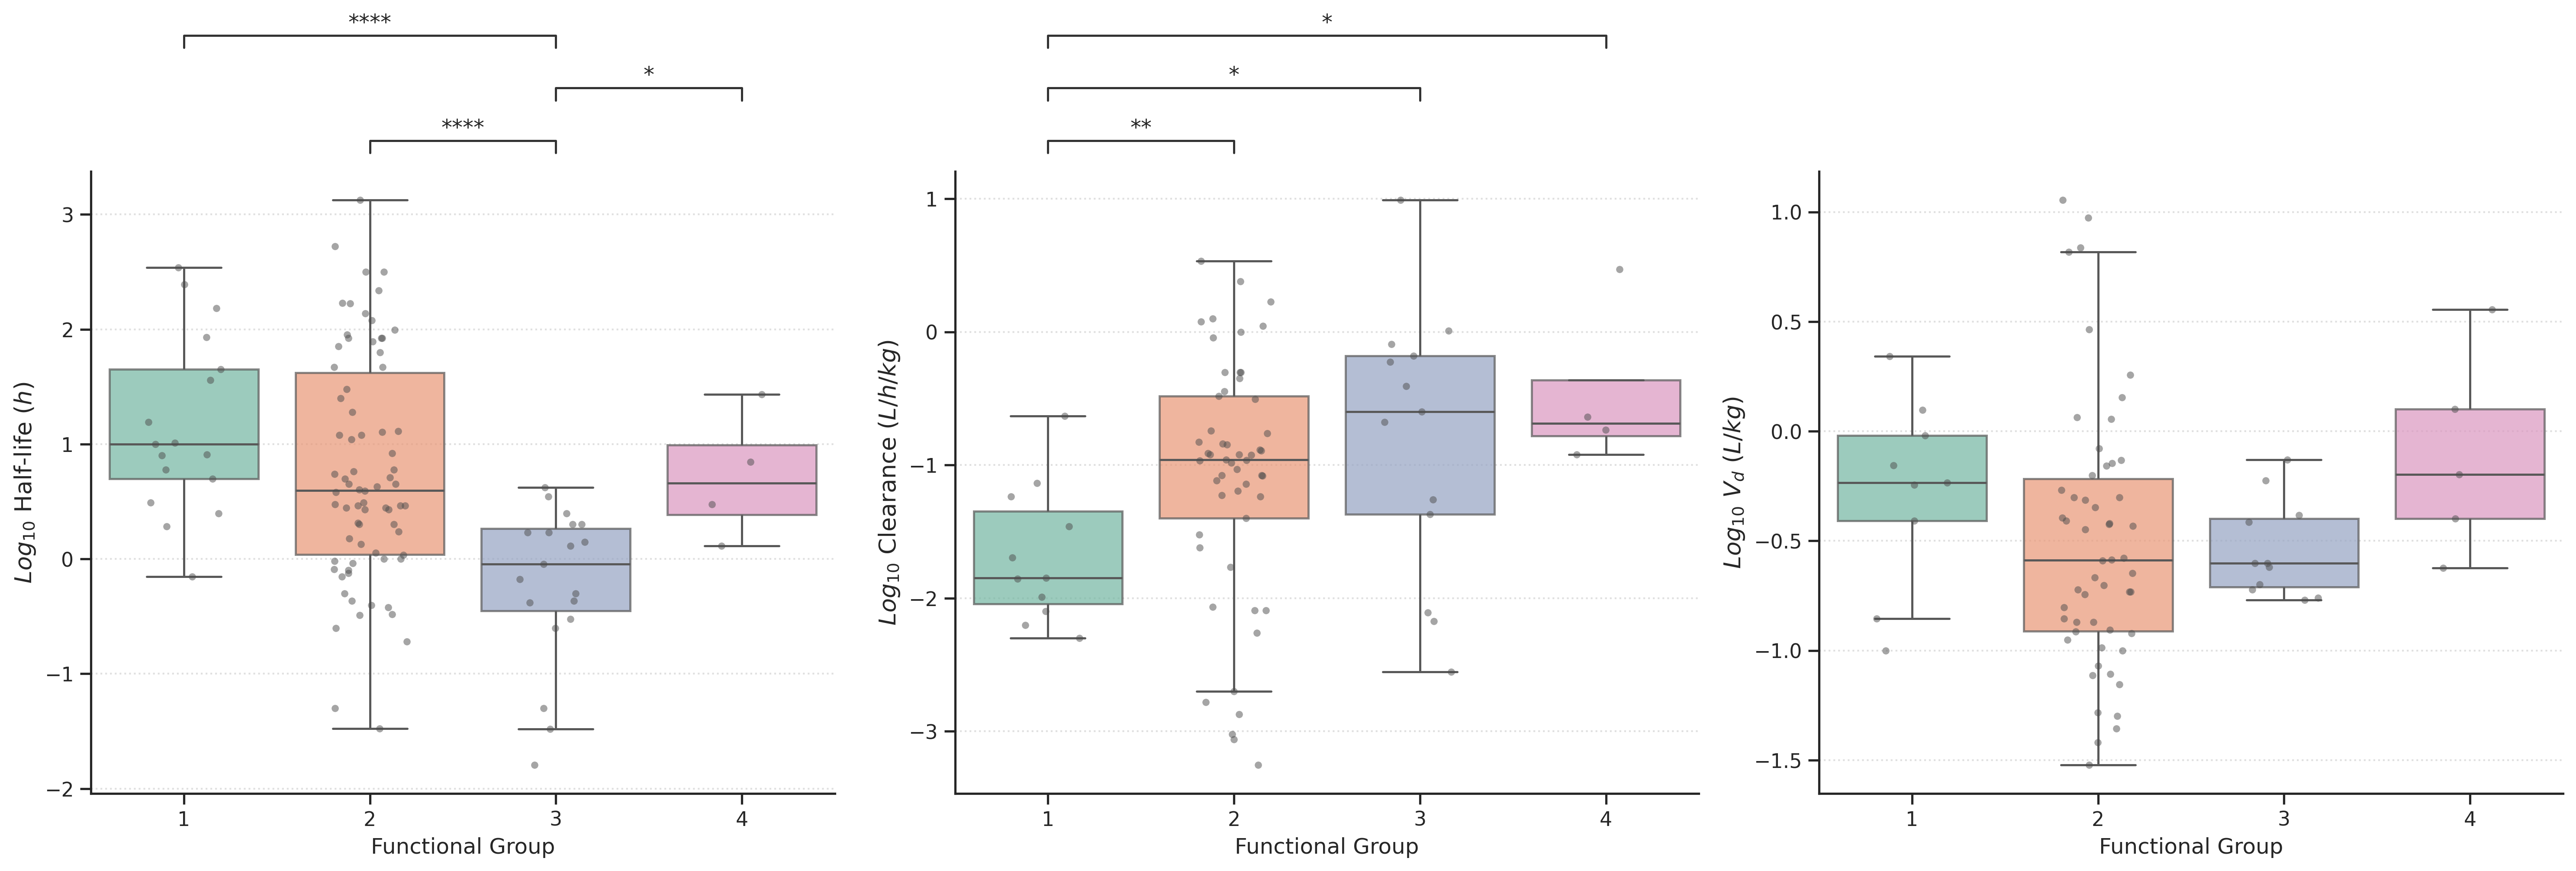

In [ ]:
# --- 1. НАСТРОЙКИ СТИЛЯ ---
sns.set_theme(style="ticks", rc={
    "axes.spines.right": False,
    "axes.spines.top": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
})

# --- 2. ПАРАМЕТРЫ И ВАШИ ДАННЫЕ СТАТИСТИКИ ---
# Добавляем Vd в список колонок
cols_to_plot = [
    'log10(Half-life, h)',
    'log10(Clearance, L/h/kg)',
    'log10(Vd, L/kg)'
]

y_labels = [
    r'$Log_{10}$ Half-life $(h)$',
    r'$Log_{10}$ Clearance $(L/h/kg)$',
    r'$Log_{10}$ $V_d$ $(L/kg)$'
]

# Ваши данные P-values (для Vd оставляем пустым)
stats_config = {
    'log10(Half-life, h)': {
        'pairs': [(2, 3), (3, 4), (1, 3)],
        'pvalues': [8.800e-05, 2.841e-02, 7.303e-06]
    },
    'log10(Clearance, L/h/kg)': {
        'pairs': [(1, 2), (1, 3), (1, 4)],
        'pvalues': [9.131e-03, 4.258e-02, 1.026e-02]
    },
    'log10(Vd, L/kg)': {
        'pairs': [], # Нет значимых различий
        'pvalues': []
    }
}

# --- 3. ОТРИСОВКА (3 столбца) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), dpi=300)
palette = sns.color_palette("Set2")

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # Боксплот
    sns.boxplot(
        x='Group', y=col, data=df_clean,
        ax=ax, palette=palette, hue='Group', legend=False,
        linewidth=1.2, fliersize=0, boxprops=dict(alpha=0.7)
    )

    # Точки (Raw data)
    sns.stripplot(
        x='Group', y=col, data=df_clean,
        ax=ax, color=".3", size=4, alpha=0.5, jitter=0.2
    )

    # Добавляем аннотации только если есть пары в конфиге
    config = stats_config.get(col)
    if config and config['pairs']:
        annotator = Annotator(ax, config['pairs'], data=df_clean, x='Group', y=col)
        annotator.set_pvalues(config['pvalues'])
        annotator.configure(text_format='star', loc='outside', line_width=1.2)
        annotator.annotate()
    else:
        # Если значимых отличий нет, можно добавить надпись "n.s." в углу или заголовок
        ax.text(0.5, 0.95, '', transform=ax.transAxes, ha='center', va='top', color='gray')

    # Оформление
    #ax.set_title(col.split('(')[1].split(',')[0].replace('log10', '').strip(),
     #            fontsize=15, fontweight='bold', pad=20)
    ax.set_ylabel(y_labels[i], fontsize=13)
    ax.set_xlabel("Functional Group", fontsize=12)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("PK_Parameters_Publication.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def generate_pk_table(df, original_cols):
    """
    df: очищенный DataFrame
    original_cols: список колонок ДО логарифмирования
    (например, ['Half-life, h', 'Clearance, L/h/kg', 'Vd, L/kg'])
    """
    results = []

    for group in sorted(df['Group'].unique()):
        group_data = df[df['Group'] == group]
        row = {'Group': f"Group {group}", 'N': len(group_data)}

        for col in original_cols:
            median = group_data[col].median()
            q1 = group_data[col].quantile(0.25)
            q3 = group_data[col].quantile(0.75)

            # Форматируем как "Медиана (IQR)"
            row[col] = f"{median:.2f} ({q1:.2f}–{q3:.2f})"

        results.append(row)

    return pd.DataFrame(results)

# Создаем таблицу
# Важно: используйте здесь имена колонок с исходными (не log10) данными
original_columns = ['Half-life, h', 'Clearance, L/h/kg', 'Vd, L/kg']
summary_table = generate_pk_table(df_clean, original_columns)

# Вывод для копирования
print(summary_table.to_string(index=False))

# Сохранение в CSV для Excel/Word
summary_table.to_csv("table_pk_summary.csv", index=False)

  Group  N       Half-life, h Clearance, L/h/kg         Vd, L/kg
Group 1 18 10.00 (5.00–45.00)  0.01 (0.01–0.05) 0.58 (0.39–0.96)
Group 2 80  3.96 (1.10–42.75)  0.11 (0.04–0.33) 0.26 (0.12–0.61)
Group 3 19   0.90 (0.36–1.85)  0.25 (0.04–0.66) 0.25 (0.20–0.40)
Group 4  7  5.00 (2.58–12.00)  0.21 (0.17–0.91) 0.64 (0.40–1.26)


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import bootstrap

def get_median_ci(data, iterations=1000):
    """Вычисляет 95% доверительный интервал для медианы."""
    if len(data) < 5: # Если данных слишком мало, CI будет некорректным
        return np.nan, np.nan

    # Bootstrap для медианы
    res = bootstrap((data,), np.median, confidence_level=0.95,
                    n_resamples=iterations, method='percentile')
    return res.confidence_interval.low, res.confidence_interval.high

def generate_full_stats_table(df, cols):
    results = []

    for group in sorted(df['Group'].unique()):
        group_data = df[df['Group'] == group]
        row = {'Group': f"Group {group}", 'N': len(group_data)}

        for col in cols:
            values = group_data[col].dropna().values
            median = np.median(values)
            low, high = get_median_ci(values)

            # Формат для статьи: Median [95% CI]
            row[f'{col} Median [95% CI]'] = f"{median:.2f} [{low:.2f} – {high:.2f}]"

        results.append(row)

    return pd.DataFrame(results)

# Используем исходные колонки (не логарифмы) для таблицы
original_columns = ['Half-life, h', 'Clearance, L/h/kg', 'Vd, L/kg']
final_stats_table = generate_full_stats_table(df_clean, original_columns)

print(final_stats_table.to_string(index=False))
final_stats_table.to_csv("PK_Detailed_Stats_CI.csv", index=False)

  Group  N Half-life, h Median [95% CI] Clearance, L/h/kg Median [95% CI] Vd, L/kg Median [95% CI]
Group 1 18         10.00 [5.00 – 45.00]                0.01 [0.01 – 0.06]       0.58 [0.14 – 1.25]
Group 2 80           3.96 [2.80 – 5.90]                0.11 [0.08 – 0.14]       0.26 [0.18 – 0.41]
Group 3 19           0.90 [0.42 – 1.70]                0.25 [0.04 – 0.66]       0.25 [0.19 – 0.41]
Group 4  7             5.00 [nan – nan]                  0.21 [nan – nan]       0.64 [0.24 – 3.60]
